<a href="https://colab.research.google.com/github/briskicedteaa/SP-Model-Repo/blob/main/Prototype_v0_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### **Sleep-State Dynamics**

For the sleep-state component of this prototype, I am adapting the [computational sleep-wake model developed by Héricé and Sakata (2019).](https://github.com/Sakata-Lab/sleep-model$0)

The model represents interacting neural populations associated with wakefulness, NREM sleep, and REM sleep and uses their changing activity to generate transitions between sleep states. The authors also released the Python code used for the model, which makes it useful as a reproducible reference rather than requiring me to design sleep-state dynamics from scratch.

I chose this model because my prototype specifically needs a way to represent REM and wake as changing states of a dynamical system. Earlier components of the prototype already represent learning, neural-population activity, and action selection. What is still missing is a model in which the simulated system can actually move between sleep states over time. This model provides an existing framework for doing that.

I am not treating this model as a computational model of sleep paralysis itself. It was developed to investigate normal sleep-wake dynamics and how different pathways affect those dynamics. For this prototype, I am using it as a reference model for sleep-state transitions. Later, only the parts necessary for testing REM-to-wake behavior will be connected to the other prototype components.

There were simpler things I could have used, including a generic two-state REM/wake model. I prefer this one for the prototype because it gives me a middle ground because it is an actual published neural-population sleep model with available Python code, but it is still focused enough that I can isolate the sleep-state dynamics we care about.

Most importantly, it gives me something my other components don't have, which is state transitions as an output.

In [7]:
#@markdown #**Setup**

!git clone https://github.com/Sakata-Lab/sleep-model.git
%cd sleep-model
import numpy as np
import os
import sleepCompModel
print(sleepCompModel)

Cloning into 'sleep-model'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 27 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 21.38 KiB | 10.69 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/sleep-model/sleep-model/sleep-model
<module 'sleepCompModel' from '/content/sleep-model/sleepCompModel.py'>


In [9]:
class SleepRegulation(object):

	def __init__(self, totalSimDuration, res, g_RRe, g_RWe, g_WNi, g_WRi, g_NRi, g_NWi):
		"""
			totalSimDuration: table with all time step values
			res: simulation resolution time
			g_RRe: weight for synapse from REM to REM
			g_RWe: weight for synapse from REM to Wake
			g_WNi: weight for synapse from Wake to NREM
			g_WRi: weight for synapse from Wake to REM
			g_NRi: weight for synapse from NREM to REM
			g_NWi: weight for synapse from NREM to Wake
		"""
		print("init_Reg")
		self.totalSimDuration = totalSimDuration
		self.res = res
		self.g_RRe = g_RRe
		self.g_RWe = g_RWe
		self.g_WNi = g_WNi
		self.g_WRi = g_WRi
		self.g_NRi = g_NRi
		self.g_NWi = g_NWi

		self.setParams()


	def heaviside(self, X):
		"""
		Heaviside step function
			X: variable to elavuate
		"""
		if (X >= 0):
			return 1
		else:
			return 0


	def generationWhiteGaussianNoise(self):
		"""
		Generation white noise values from a Gaussian distribution for each time step of the simulation
		"""
		self.meanNoise = 0.01 #0
		self.stdNoise = 0.015 #0.005 # 0.01
		noiseSample = np.random.normal(self.meanNoise, self.stdNoise, size=(int(self.totalSimDuration * self.res)))
		return noiseSample


	def getWhiteGaussianNoise(self, noiseValues, i):
		"""
		Returns the noise value corresponding to the current time step
			noiseValues: table with all noise values for every time step
			i: current time step
		"""
		currentNoise = noiseValues[i]
		return currentNoise


	def set_RK(self, N, dt, noiseValues, i):
		"""
		ODE functions - SRK iterations
			N: RK moment
			dt: time step
			noiseValues: table with all noise values for every time step
			i: time step
		"""

		# Populations firing rates
		self.f_W[N+1] = self.f_W[0] + self.A[N] * dt * (self.F_W_max * 0.5 * (1 + np.tanh((self.I_W(N, noiseValues, i) - self.beta_W) 				/ self.alpha_W)) - self.f_W[N]) / self.tau_W
		self.f_N[N+1] = self.f_N[0] + self.A[N] * dt * (self.F_N_max * 0.5 * (1 + np.tanh((self.I_N(N, noiseValues, i) + self.kappa * self.h[N]) 	/ self.alpha_N)) - self.f_N[N]) / self.tau_N
		self.f_R[N+1] = self.f_R[0] + self.A[N] * dt * (self.F_R_max * 0.5 * (1 + np.tanh((self.I_R(N, noiseValues, i) - self.beta_R) 				/ self.alpha_R)) - self.f_R[N]) / self.tau_R

		# Neurotransmitters concentrations
		self.c_WXi[N+1] = self.c_WXi[0] + self.A[N] * dt * (np.tanh(self.f_W[N+1] / self.gamma_E) - self.c_WXi[N]) / self.tau_E
		self.c_NXi[N+1] = self.c_NXi[0] + self.A[N] * dt * (np.tanh(self.f_N[N+1] / self.gamma_G) - self.c_NXi[N]) / self.tau_G
		self.c_RXe[N+1] = self.c_RXe[0] + self.A[N] * dt * (np.tanh(self.f_R[N+1] / self.gamma_A) - self.c_RXe[N]) / self.tau_A

		# Homeostatic force
		self.h[N+1]   = self.h[0]   + self.A[N] * dt * ((self.H_max - self.h[N]) / self.tau_hw * self.heaviside(self.f_W[N] - self.theta_W) - self.h[N] / self.tau_hs * self.heaviside(self.theta_W - self.f_W[N]))


	def add_RK2(self, var):
		"""
		RK2 iteration
			var: list of the RK moments to iterate
		"""
		var[0] = (-3 * var[0] + 2 * var[1] + 4 * var[2] + 2 * var[3] + var[4]) / 6


	def add_RK1(self):
		"""
		RK1 iteration
		"""
		self.add_RK2(self.f_W)
		self.add_RK2(self.f_N)
		self.add_RK2(self.f_R)
		self.add_RK2(self.c_WXi)
		self.add_RK2(self.c_NXi)
		self.add_RK2(self.c_RXe)
		self.add_RK2(self.h)


	def I_W(self, N, noiseValues, i):
		"""
		Wake input function
			N: RK moment
			noiseValues: table with all noise values for every time step
			i: time step
		"""
		return self.g_NWi * self.c_NXi[N] + self.g_RWe * self.c_RXe[N] + self.getWhiteGaussianNoise(noiseValues, i)


	def I_N(self, N, noiseValues, i):
		"""
		NREM input function
			N: RK moment
			noiseValues: table with all noise values for every time step
			i: time step
		"""
		return self.g_WNi * self.c_WXi[N] + self.getWhiteGaussianNoise(noiseValues, i)


	def I_R(self, N, noiseValues, i):
		"""
		REM input function
			N: RK moment
			noiseValues: table with all noise values for every time step
			i: time step
		"""
		return self.g_WRi * self.c_WXi[N] + self.g_NRi * self.c_NXi[N] + self.g_RRe * self.c_RXe[N] + self.getWhiteGaussianNoise(noiseValues, i)


	def initVal(self, value):
		"""
		Initialise paramters
			value: initial value for the parameter
		"""
		return [value, 0.0, 0.0, 0.0, 0.0]


	def setParams(self):
		"""
		Setting initial parameters values for the model
		"""
		# Membrane time in [s]
		self.tau_W = 1500e3
		self.tau_N = 600e3
		self.tau_R = 60e3

		# Neurotransmitter time constants in [s]
		self.tau_E = 25e3
		self.tau_G = 10e3
		self.tau_A = 10e3

		# Maximum firing rate in [Hz]
		self.F_W_max = 6.5
		self.F_N_max = 5.
		self.F_R_max = 5.

		# Sigmoid slope parameters in [aU]
		self.alpha_W = 0.5
		self.alpha_N = 0.175
		self.alpha_R = 0.13

		# Sigmoid threshold parameters in [aU]
		self.beta_W = -0.4
		self.beta_R = -0.9

		# Neurotransmitter release scaling in [s^-1]
		self.gamma_E = 5.
		self.gamma_G = 4.
		self.gamma_A = 2.

		# # Synaptic weights for neurotransmitter efficacy in [aU]
		# self.g_RRe = g_RRe 			# REM to REM
		# self.g_RWe = g_RWe			# REM to Wake
		# self.g_WNi = g_WNi 			# Wake to NREM
		# self.g_WRi = g_WRi 			# Wake to REM
		# self.g_NRi = g_NRi 			# NREM to REM
		# self.g_NWi = g_NWi 			# NREM to Wake

		# Sleep Homeostasis parameter
		self.H_max 		= 1. 		# in [aU]
		self.theta_W 	= 2. 		# in [s]
		self.tau_hw 	= 34830e3 	# 580.5 min in [s]
		self.tau_hs 	= 30600e3 	# 510 min in [s]
		self.kappa 		= 1.5 		# in [aU]

		# SRK integration parameters
		self.A = [0.5, 0.5, 1.0, 1.0]

		# Wake-population input pulses parameters
		self.etaCpt = 0
		self.eta 	= 0

		# Declaration and initialization of variables
		self.f_W		= self.initVal(6.) 		# Wake promoting activity	in [Hz]
		self.f_N		= self.initVal(1e-3) 	# Sleep promoting activity	in [Hz]
		self.f_R		= self.initVal(1e-3) 	# REM promoting activity	in [Hz]
		self.c_WXi		= self.initVal(0.9) 	# Norephrine concentration	in [aU]
		self.c_NXi		= self.initVal(1e-3) 	# GABA concentration		in [aU]
		self.c_RXe		= self.initVal(1e-3) 	# Acetylcholin concentration in [aU]
		self.h			= self.initVal(0.5) 	# Homeostatic sleep drive	in [aU]


################################################
# Run simulation
################################################

class RunSim(object):

	def __init__(self, simDuration, simNumber, alterationSite, dirName, g_RRe, g_RWe, g_WNi, g_WRi, g_NRi, g_NWi):
		"""
			simDuration: simulation duration in hours
			simNumber: current simulation number
			alterationSite: name of the altered synapse
			dirName: main directory for synaptic alteration condition
			g_RRe: weight for synapse from REM to REM
			g_RWe: weight for synapse from REM to Wake
			g_WNi: weight for synapse from Wake to NREM
			g_WRi: weight for synapse from Wake to REM
			g_NRi: weight for synapse from NREM to REM
			g_NWi: weight for synapse from NREM to Wake
		"""
		print("init_RunSim")
		self.simDuration = simDuration
		self.simNumber = simNumber
		self.alterationSite = alterationSite
		self.dirName = dirName
		self.g_RRe = g_RRe
		self.g_RWe = g_RWe
		self.g_WNi = g_WNi
		self.g_WRi = g_WRi
		self.g_NRi = g_NRi
		self.g_NWi = g_NWi

		self.setSimParam()
		self.Sleep_Reg = SleepRegulation(self.totalSimDuration, self.res, g_RRe, g_RWe, g_WNi, g_WRi, g_NRi, g_NWi)
		self.runSimulation()
		self.saveResults()


	def setSimParam(self):
		"""
		Setting initial parameters values for the simulation
		"""
		self.res = 1 #1 		# Number of iteration steps per s
		self.dt = 1e3 / self.res 		# Duration of a time step in ms

		self.simDurationHours = self.simDuration  	# ~ 2 min per H on Core i7
		self.totalSimDuration = self.simDurationHours * 3600 			# Duration of the simulation in s

		self.noiseValues = []

		self.F_R = []
		self.F_W = []
		self.F_N = []
		self.C_RXe = []
		self.C_NXi = []
		self.C_WXi = []
		self.tempTime = []
		self.HOMEO = []

		# Simulation
		# startTime = time.time()

		self.tempTime = np.linspace(0, self.totalSimDuration, int(self.totalSimDuration * self.res))


	def ODE(self, noiseValues, i):
		"""
		First calculate every ith RK moment.
		Has to be in order, 1th moment first
			noiseValues: table with all noise values for every time step
			i: time step
		"""
		for y in range(4):
			self.Sleep_Reg.set_RK(y, self.dt, noiseValues, i)

		# Add all moments
		self.Sleep_Reg.add_RK1()


	def runSimulation(self):
		"""
		Run simulation
		"""
		self.noiseValues = self.Sleep_Reg.generationWhiteGaussianNoise()

		for i in range(int(self.totalSimDuration * self.res)):
			if (i%1000 == 0):
				print("- Step", round((i/3600), 1), "on", (self.totalSimDuration * self.res / 3600), "-", self.dirName, self.alterationSite, self.simNumber)
			self.ODE(self.noiseValues, i)
			self.F_R.append(self.Sleep_Reg.f_R[3])
			self.F_W.append(self.Sleep_Reg.f_W[3])
			self.F_N.append(self.Sleep_Reg.f_N[3])
			self.C_WXi.append(self.Sleep_Reg.c_WXi[3])
			self.C_NXi.append(self.Sleep_Reg.c_NXi[3])
			self.C_RXe.append(self.Sleep_Reg.c_RXe[3])
			self.HOMEO.append(self.Sleep_Reg.h[3])


	def saveResults(self):
		"""
		Save results in data files
		"""
		print("-- Saving results")

		# Directory for synaptic alteration condition
		self.alterationDirName = self.dirName
		if (os.path.isdir(self.alterationDirName) == False):
			os.mkdir(self.alterationDirName)

		# Directory for the altered synapse condition
		self.synapseDirName = self.alterationDirName + "/Alterations_" + self.alterationSite + "_" + str(self.simDuration) + "h"
		if (os.path.isdir(self.synapseDirName) == False):
			os.mkdir(self.synapseDirName)

		# Directory for the simulation number
		self.simNbDirName = self.synapseDirName + "/Sim" + str(self.simNumber)
		if (os.path.isdir(self.simNbDirName) == False):
			os.mkdir(self.simNbDirName)

		# Saving data into npy files
		np.save((self.simNbDirName + "/time_Herice_Model_Alteration_" 	+ self.dirName + "_" + self.alterationSite + "_sim" + str(self.simNumber) + ".npy"), self.tempTime)
		np.save((self.simNbDirName + "/f_R_Herice_Model_Alteration_" 	+ self.dirName + "_" + self.alterationSite + "_sim" + str(self.simNumber) + ".npy"), self.F_R)
		np.save((self.simNbDirName + "/f_N_Herice_Model_Alteration_" 	+ self.dirName + "_" + self.alterationSite + "_sim" + str(self.simNumber) + ".npy"), self.F_N)
		np.save((self.simNbDirName + "/f_W_Herice_Model_Alteration_" 	+ self.dirName + "_" + self.alterationSite + "_sim" + str(self.simNumber) + ".npy"), self.F_W)
		np.save((self.simNbDirName + "/C_NXi_Herice_Model_Alteration_" 	+ self.dirName + "_" + self.alterationSite + "_sim" + str(self.simNumber) + ".npy"), self.C_NXi)
		np.save((self.simNbDirName + "/C_WXi_Herice_Model_Alteration_" 	+ self.dirName + "_" + self.alterationSite + "_sim" + str(self.simNumber) + ".npy"), self.C_WXi)
		np.save((self.simNbDirName + "/C_RXe_Herice_Model_Alteration_" 	+ self.dirName + "_" + self.alterationSite + "_sim" + str(self.simNumber) + ".npy"), self.C_RXe)
		np.save((self.simNbDirName + "/h_Herice_Model_Alteration_"   	+ self.dirName + "_" + self.alterationSite + "_sim" + str(self.simNumber) + ".npy"), self.HOMEO)

		# Saving data into  files
		np.savetxt((self.simNbDirName + "/time" + ".csv"), self.tempTime)
		np.savetxt((self.simNbDirName + "/f_R" + ".csv"), self.F_R)
		np.savetxt((self.simNbDirName + "/f_N" + ".csv"), self.F_N)
		np.savetxt((self.simNbDirName + "/f_W" + ".csv"), self.F_W)
		np.savetxt((self.simNbDirName + "/C_NXi" + ".csv"), self.C_NXi)
		np.savetxt((self.simNbDirName + "/C_WXi" + ".csv"), self.C_WXi)
		np.savetxt((self.simNbDirName + "/C_RXe" + ".csv"), self.C_RXe)
		np.savetxt((self.simNbDirName + "/h" + ".csv"), self.HOMEO)

# **Manipulations.py**

In [10]:
print("--")

simDuration = 24
nbSims = 8
toShow = "n"



# default params
g_RRe = 1.6
g_RWe = 1.0
g_WNi = -2.0
g_WRi = -4.0
g_NRi = -1.3
g_NWi = -1.68

Ratios = np.array([0, 1/8, 1/4, 1/2, 1, 2, 4, 8])

# core - REM
dirName = "REM"

for simNumber in range(1, nbSims):
	ctr1 = 0
	for i in Ratios:
		ctr1 += 1
		ctr2 = 0
		for j in Ratios:
			ctr2 += 1
			alterationSite = "REM"+"_R"+str(ctr1)+"_W"+str(ctr2)
			print(alterationSite)

			sleepCompModel.RunSim(simDuration, simNumber, alterationSite, dirName, g_RRe*i, g_RWe*j, g_WNi, g_WRi, g_NRi, g_NWi)

# core - AW
dirName = "AW"

for simNumber in range(1, nbSims):
	ctr1 = 0
	for i in Ratios:
		ctr1 += 1
		ctr2 = 0
		for j in Ratios:
			ctr2 += 1
			alterationSite = "AW"+"_N"+str(ctr1)+"_R"+str(ctr2)
			print(alterationSite)

			sleepCompModel.RunSim(simDuration, simNumber, alterationSite, dirName, g_RRe, g_RWe, g_WNi*i, g_WRi*j, g_NRi, g_NWi)

# core - NREM
dirName = "NREM"

for simNumber in range(1, nbSims):
	ctr1 = 0
	for i in Ratios:
		ctr1 += 1
		ctr2 = 0
		for j in Ratios:
			ctr2 += 1
			alterationSite = "NREM"+"_R"+str(ctr1)+"_W"+str(ctr2)
			print(alterationSite)

			sleepCompModel.RunSim(simDuration, simNumber, alterationSite, dirName, g_RRe, g_RWe, g_WNi, g_WRi, g_NRi*i, g_NWi*j)


Streaming output truncated to the last 5000 lines.
- Step 3.1 on 24.0 - REM REM_R7_W4 1
- Step 3.3 on 24.0 - REM REM_R7_W4 1
- Step 3.6 on 24.0 - REM REM_R7_W4 1
- Step 3.9 on 24.0 - REM REM_R7_W4 1
- Step 4.2 on 24.0 - REM REM_R7_W4 1
- Step 4.4 on 24.0 - REM REM_R7_W4 1
- Step 4.7 on 24.0 - REM REM_R7_W4 1
- Step 5.0 on 24.0 - REM REM_R7_W4 1
- Step 5.3 on 24.0 - REM REM_R7_W4 1
- Step 5.6 on 24.0 - REM REM_R7_W4 1
- Step 5.8 on 24.0 - REM REM_R7_W4 1
- Step 6.1 on 24.0 - REM REM_R7_W4 1
- Step 6.4 on 24.0 - REM REM_R7_W4 1
- Step 6.7 on 24.0 - REM REM_R7_W4 1
- Step 6.9 on 24.0 - REM REM_R7_W4 1
- Step 7.2 on 24.0 - REM REM_R7_W4 1
- Step 7.5 on 24.0 - REM REM_R7_W4 1
- Step 7.8 on 24.0 - REM REM_R7_W4 1
- Step 8.1 on 24.0 - REM REM_R7_W4 1
- Step 8.3 on 24.0 - REM REM_R7_W4 1
- Step 8.6 on 24.0 - REM REM_R7_W4 1
- Step 8.9 on 24.0 - REM REM_R7_W4 1
- Step 9.2 on 24.0 - REM REM_R7_W4 1
- Step 9.4 on 24.0 - REM REM_R7_W4 1
- Step 9.7 on 24.0 - REM REM_R7_W4 1
- Step 10.0 on 24.0 - RE

KeyboardInterrupt: 

Small test just to make sure the authors' model runs correctly in Colab before I compute a longer sleep simulation

In [11]:
g_RRe = 1.6
g_RWe = 1.0
g_WNi = -2.0
g_WRi = -4.0
g_NRi = -1.3
g_NWi = -1.68

In [12]:
baseline = sleepCompModel.RunSim(
    1,
    1,
    "baseline",
    "Baseline",
    g_RRe,
    g_RWe,
    g_WNi,
    g_WRi,
    g_NRi,
    g_NWi
)

init_RunSim
init_Reg
- Step 0.0 on 1.0 - Baseline baseline 1
- Step 0.3 on 1.0 - Baseline baseline 1
- Step 0.6 on 1.0 - Baseline baseline 1
- Step 0.8 on 1.0 - Baseline baseline 1
-- Saving results


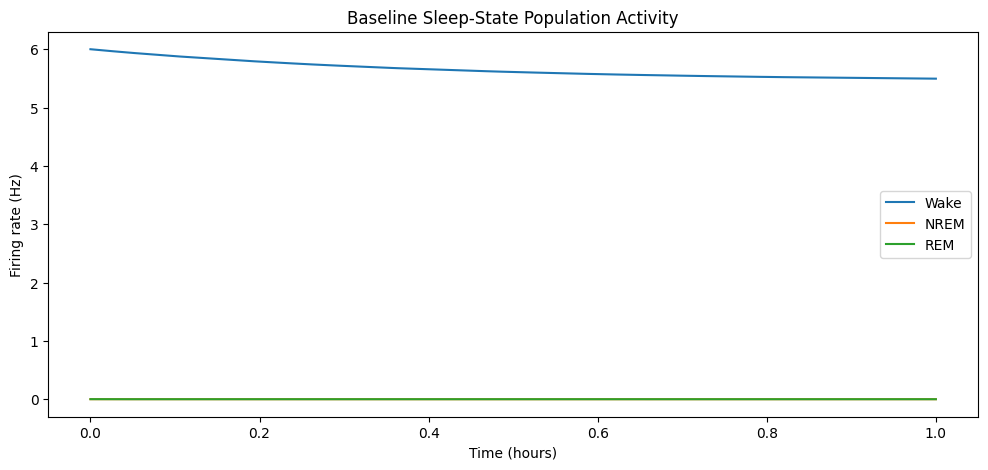

In [14]:
#@markdown #### **Plot**

#@markdown The model stayed basically awake for the entire first simulated hour. Wake activity starts around 6 Hz and slowly falls toward about 5.5 Hz, while NREM and REM stay essentially at zero. So there was no state transition yet.

#@markdown That actually matches the behavior the authors describe: their model deliberately starts with high Wake-population activity, then the homeostatic sleep drive gradually builds during wakefulness until Wake activity eventually drops and the model enters NREM. REM/NREM alternations happen later.

import matplotlib.pyplot as plt

time_hours = baseline.tempTime / 3600

plt.figure(figsize=(12, 5))

plt.plot(time_hours, baseline.F_W, label="Wake")
plt.plot(time_hours, baseline.F_N, label="NREM")
plt.plot(time_hours, baseline.F_R, label="REM")

plt.xlabel("Time (hours)")
plt.ylabel("Firing rate (Hz)")
plt.title("Baseline Sleep-State Population Activity")
plt.legend()

plt.show()